<a href="https://colab.research.google.com/github/wahyuimammuhroni-jpg/ecommerce-order-supply-chain-analysis/blob/main/notebooks/ecommerce_order_supply_chain_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ecommerce Order & Supply Chain Visualization  

## Project Overview  

Dataset ini berisi data transaksi e-commerce yang mencakup informasi mengenai pesanan, produk, pelanggan, seller, pembayaran, serta proses pengiriman.

Notebook ini berfokus pada visualisasi hasil analisis yang telah dilakukan menggunakan Python dan BigQuery SQL untuk memahami performa bisnis e-commerce dari berbagai perspektif, termasuk tren penjualan, perilaku customer, performa produk, kontribusi seller, serta efektivitas proses logistik.

Analisis visualisasi ini bertujuan untuk mengubah hasil pengolahan data menjadi insight bisnis yang lebih mudah dipahami melalui dashboard dan visual representation.

## Dataset Overview

Dataset terdiri dari beberapa tabel yang saling berhubungan melalui beberapa key utama seperti:

- `order_id` : Unique identifier untuk setiap transaksi pesanan.
- `customer_id` : Identifier customer yang melakukan transaksi.
- `product_id` : Identifier produk yang dibeli.
- `seller_id` : Identifier seller yang menyediakan produk.

Tabel utama yang digunakan dalam analisis meliputi:  

### Orders

Berisi informasi utama mengenai transaksi dan proses pengiriman.

- `order_id` : ID unik setiap pesanan.
- `customer_id` : ID customer.
- `order_status` : Status transaksi.
- `order_purchase_timestamp` : Waktu transaksi dibuat.
- `delivery_days` : Durasi proses pengiriman.
- `delivery_status` : Status ketepatan pengiriman.  

### Order Items

Berisi informasi produk dan seller pada setiap transaksi.

- `order_id` : ID pesanan.
- `product_id` : ID produk.
- `seller_id` : ID seller.
- `price` : Harga produk.
- `shipping_charges` : Biaya pengiriman.  

### Products

Berisi informasi kategori dan dimensi produk.

- `product_id` : ID unik produk.
- `product_category_name` : Kategori produk.
- `product_weight_g` : Berat produk.  

### Customers

Berisi informasi lokasi customer.

- `customer_id` : ID customer.
- `customer_city` : Kota customer.
- `customer_state` : Wilayah customer.

### Payments

Berisi informasi metode pembayaran customer.

- `order_id` : ID pesanan.
- `payment_type` : Metode pembayaran.
- `payment_installments` : Jumlah cicilan.
- `payment_value` : Nilai pembayaran.

## Analysis Scope

Visualisasi dalam notebook ini mencakup beberapa area analisis utama:

1. **Business Performance**
   - Total sales
   - Total orders
   - Average order value
   - Sales trend

2. **Customer Analysis**
   - Customer distribution
   - Customer spending segmentation

3. **Product Analysis**
   - Product category performance
   - Product ranking performance

4. **Seller Analysis**
   - Seller contribution
   - Revenue concentration (Pareto Analysis)

5. **Supply Chain Analysis**
   - Delivery performance
   - Late delivery analysis

## Tools & Technologies

Tools yang digunakan dalam project ini:

- Python (Google Colab)
- Pandas
- Matplotlib
- BigQuery SQL
- Kaggle Dataset

Workflow:

Raw Dataset  
↓  
Data Cleaning & Feature Engineering (Python)  
↓  
Business Analysis (BigQuery SQL)  
↓  
Visualization & Business Insight (Python & Google Looker Studio)

## Import Library

In [21]:
# Import Library
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Load Data from BigQuery

In [22]:
# Load Data from BigQuery
from google.colab import auth
auth.authenticate_user()
from google.cloud import bigquery
!pip install google-cloud-bigquery

client = bigquery.Client(
    project="projek-muhroni-dqlab"
)
def run_query(query):
    query_job = client.query(query)
    return query_job.to_dataframe()

## Executive Overview Dashboard

Dashboard ini memberikan ringkasan performa utama bisnis e-commerce berdasarkan metrik transaksi, revenue, dan operasional pengiriman.

Metric utama yang dianalisis:

- Total Orders
- Total Sales
- Average Order Value
- Late Delivery Rate

### KPI Data

In [23]:
# Load KPI Data
overview_query = """

SELECT

COUNT(DISTINCT o.order_id) AS total_orders,

ROUND(
SUM(oi.price),
2
) AS total_sales,

ROUND(
AVG(oi.order_value),
2
) AS average_order_value

FROM ecommerce.orders AS o

JOIN ecommerce.order_items AS oi

ON o.order_id = oi.order_id

WHERE
o.order_status = 'delivered'

"""

overview_df = run_query(overview_query)

overview_df

,total_orders,total_sales,average_order_value
0,87428,29925513.630000000,386.530000000


### Late Delivery Rate

In [24]:
# Load Late Delivery Rate
delivery_query = """

SELECT

ROUND(

SAFE_DIVIDE(

COUNTIF(delivery_status = 'Late'),

COUNTIF(delivery_status IN ('Late','On Time'))

) * 100,

2

) AS late_delivery_rate

FROM ecommerce.orders

WHERE
delivery_status != 'Not Delivered'

"""

delivery_df = run_query(delivery_query)

delivery_df

,late_delivery_rate
0,7.71


### Combine KPI

In [25]:
# Combine KPI
total_orders = overview_df["total_orders"][0]
total_sales = overview_df["total_sales"][0]
average_order_value = overview_df["average_order_value"][0]
late_delivery_rate = delivery_df["late_delivery_rate"][0]

print("Total Orders:", total_orders)
print("Total Sales:", total_sales)
print("Average Order Value:", average_order_value)
print("Late Delivery Rate:", late_delivery_rate,"%")

Total Orders: 87428
Total Sales: 29925513.630000000
Average Order Value: 386.530000000
Late Delivery Rate: 7.71 %


### Executive KPI Visualization Overview

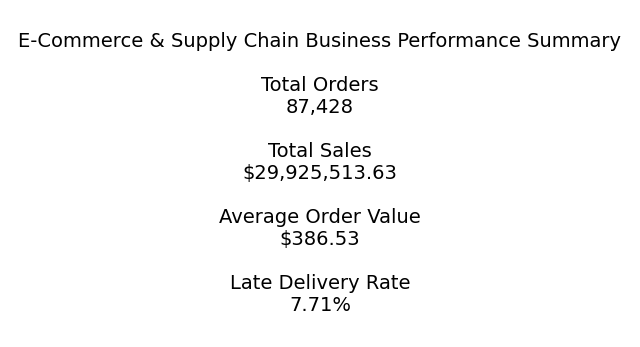

In [26]:
# Create KPI Dashboard
fig, ax = plt.subplots(figsize=(8, 3))

ax.axis("off")

kpi_text = f"""
E-Commerce & Supply Chain Business Performance Summary

Total Orders
{total_orders:,}

Total Sales
${total_sales:,.2f}

Average Order Value
${average_order_value:,.2f}

Late Delivery Rate
{late_delivery_rate:.2f}%
"""

ax.text(
    0.5,
    0.5,
    kpi_text,
    ha="center",
    va="center",
    fontsize=14
)


plt.show()

## Analysis Product Sales & Order Trends  

- **Sales**  
Visualisasi ini digunakan untuk melihat perkembangan performa penjualan e-commerce dari waktu ke waktu berdasarkan transaksi dengan status `delivered`. Analisis berfokus pada perubahan total sales dan jumlah order setiap bulan untuk mengidentifikasi pola pertumbuhan maupun penurunan performa bisnis.

- **Order**  
Visualisasi ini digunakan untuk melihat perubahan jumlah order dari waktu ke waktu dan membandingkannya dengan pola sales bulanan. Analisis ini membantu mengidentifikasi apakah pertumbuhan sales terutama dipengaruhi oleh peningkatan volume transaksi.

### Sales and Order Trends

In [27]:
# Load Sales and Order Trend
sales_and_order_trend_query = """

SELECT

    DATE_TRUNC(
        DATE(o.order_purchase_timestamp),
        MONTH
    ) AS month_date,

    FORMAT_DATE(
        '%Y-%B',
        DATE(o.order_purchase_timestamp)
    ) AS purchase_month,

    COUNT(DISTINCT o.order_id) AS total_orders,

    ROUND(
        SUM(oi.price),
        2
    ) AS total_sales

FROM ecommerce.orders AS o

JOIN ecommerce.order_items AS oi
    ON o.order_id = oi.order_id

WHERE
    o.order_status = 'delivered'

GROUP BY
    month_date,
    purchase_month

ORDER BY
    month_date ASC

"""

sales_and_order_trend_df = run_query(sales_and_order_trend_query)

sales_and_order_trend_df

,month_date,purchase_month,total_orders,total_sales
0,2016-10-01,2016-October,256,87453.550000000
1,2016-12-01,2016-December,1,215.940000000
2,2017-01-01,2017-January,824,231539.380000000
3,2017-02-01,2017-February,1467,426872.750000000
4,2017-03-01,2017-March,2316,799208.640000000
5,2017-04-01,2017-April,2042,701127.960000000
6,2017-05-01,2017-May,3301,1007240.810000000
7,2017-06-01,2017-June,2884,896081.470000000
8,2017-07-01,2017-July,3699,1190242.860000000
9,2017-08-01,2017-August,3942,1251579.030000000


### Monthly Sales Trend Visualization

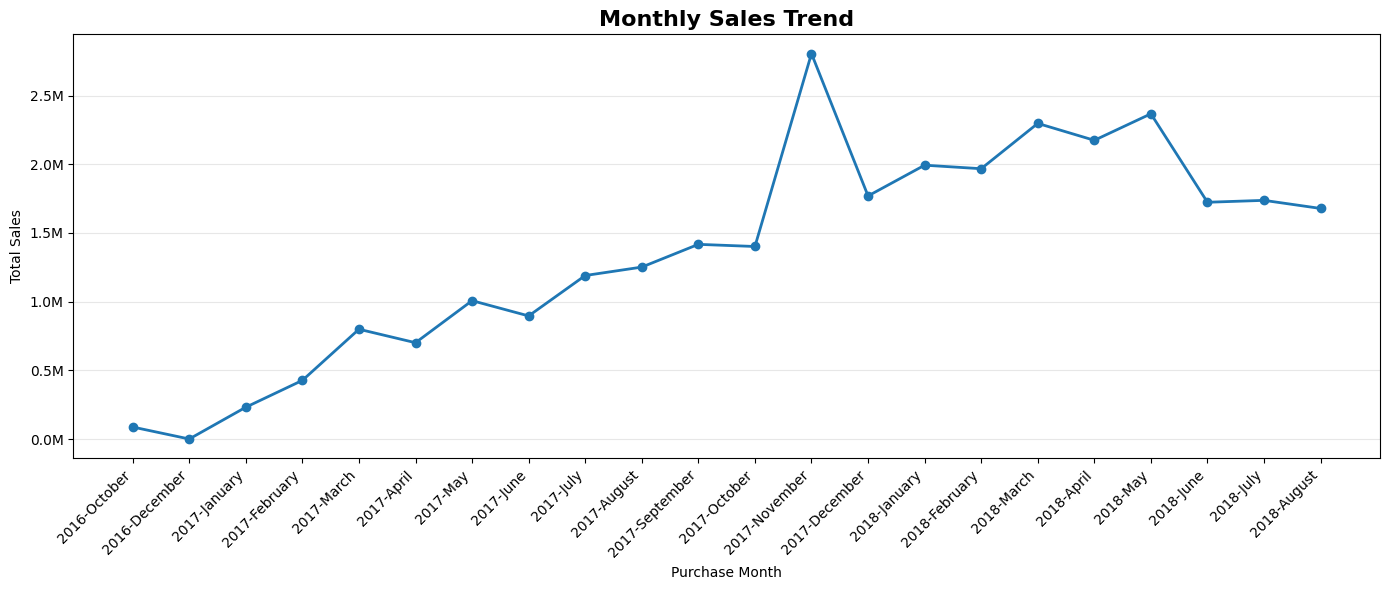


Highest Sales Month:
month_date               2017-11-01
purchase_month        2017-November
total_orders                   6694
total_sales       2805670.420000000
Name: 12, dtype: object

Lowest Sales Month:
month_date           2016-12-01
purchase_month    2016-December
total_orders                  1
total_sales       215.940000000
Name: 1, dtype: object


In [28]:
# Monthly Sales Trend Visualization
plt.figure(figsize=(14, 6))

plt.plot(
    sales_and_order_trend_df["purchase_month"],
    sales_and_order_trend_df["total_sales"],
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Sales Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Purchase Month")
plt.ylabel("Total Sales")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x/1_000_000:.1f}M"
    )
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

highest_sales_month = sales_and_order_trend_df.loc[
    sales_and_order_trend_df["total_sales"].idxmax()
]

lowest_sales_month = sales_and_order_trend_df.loc[
    sales_and_order_trend_df["total_sales"].idxmin()
]

print("\nHighest Sales Month:")
print(highest_sales_month)

print("\nLowest Sales Month:")
print(lowest_sales_month)

### Monthly Order Trend Visualization


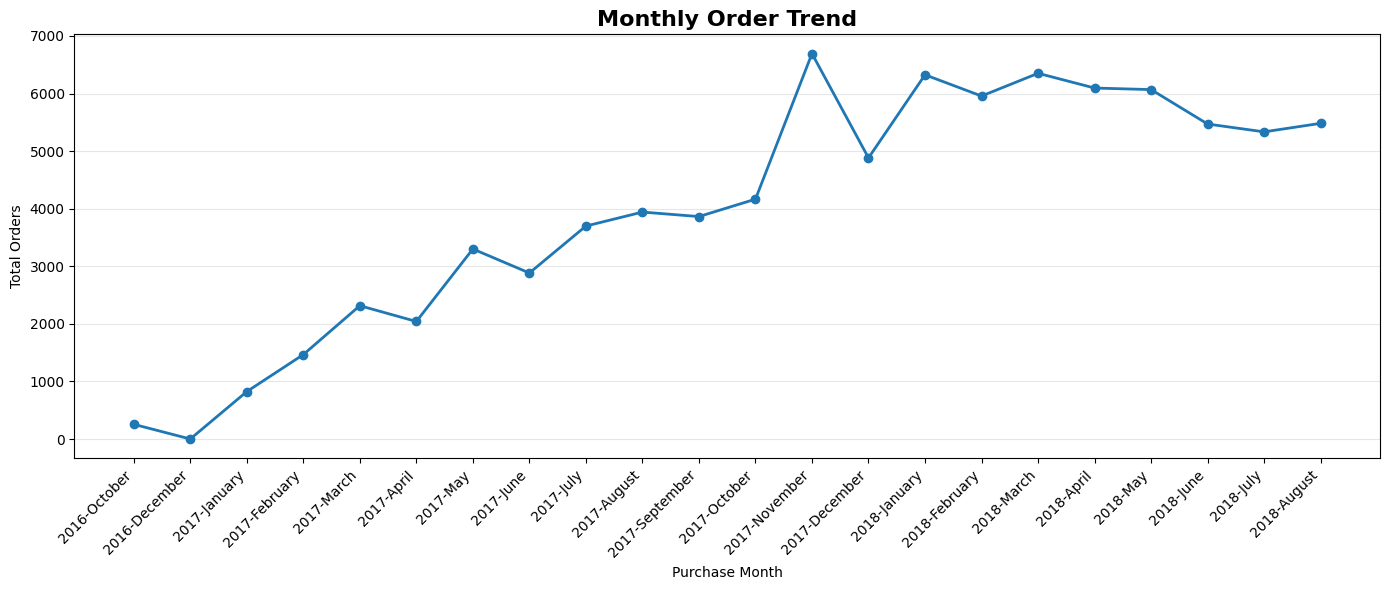


Highest Order Month:
month_date               2017-11-01
purchase_month        2017-November
total_orders                   6694
total_sales       2805670.420000000
Name: 12, dtype: object

Lowest Order Month:
month_date           2016-12-01
purchase_month    2016-December
total_orders                  1
total_sales       215.940000000
Name: 1, dtype: object


In [29]:
# Monthly Order Trend Visualization
plt.figure(figsize=(14, 6))

plt.plot(
    sales_and_order_trend_df["purchase_month"],
    sales_and_order_trend_df["total_orders"],
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Order Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Purchase Month")
plt.ylabel("Total Orders")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

highest_order_month = sales_and_order_trend_df.loc[
    sales_and_order_trend_df["total_orders"].idxmax()
]

lowest_order_month = sales_and_order_trend_df.loc[
    sales_and_order_trend_df["total_orders"].idxmin()
]

print("\nHighest Order Month:")
print(highest_order_month)

print("\nLowest Order Month:")
print(lowest_order_month)

### Product Category Performance Visualization

In [30]:
# Load Product Category Performance
product_category_query = """

SELECT
    p.product_category_name,

    COUNT(DISTINCT o.order_id) AS total_orders,

    ROUND(
        SUM(oi.price),
        2
    ) AS total_sales

FROM ecommerce.orders AS o

JOIN ecommerce.order_items AS oi
    ON o.order_id = oi.order_id

JOIN ecommerce.products AS p
    ON oi.product_id = p.product_id

WHERE
    o.order_status = 'delivered'

GROUP BY
    p.product_category_name

ORDER BY
    total_sales DESC

LIMIT 10

"""

product_category_df = run_query(product_category_query)

product_category_df

,product_category_name,total_orders,total_sales
0,toys,65643,22613413.450000000
1,furniture_decor,1723,739082.570000000
2,garden_tools,777,732447.160000000
3,bed_bath_table,2119,594526.860000000
4,health_beauty,2289,581728.490000000
5,watches_gifts,1177,577406.420000000
6,sports_leisure,1799,530014.030000000
7,telephony,891,491089.470000000
8,computers_accessories,1673,423136.320000000
9,housewares,1301,406031.190000000


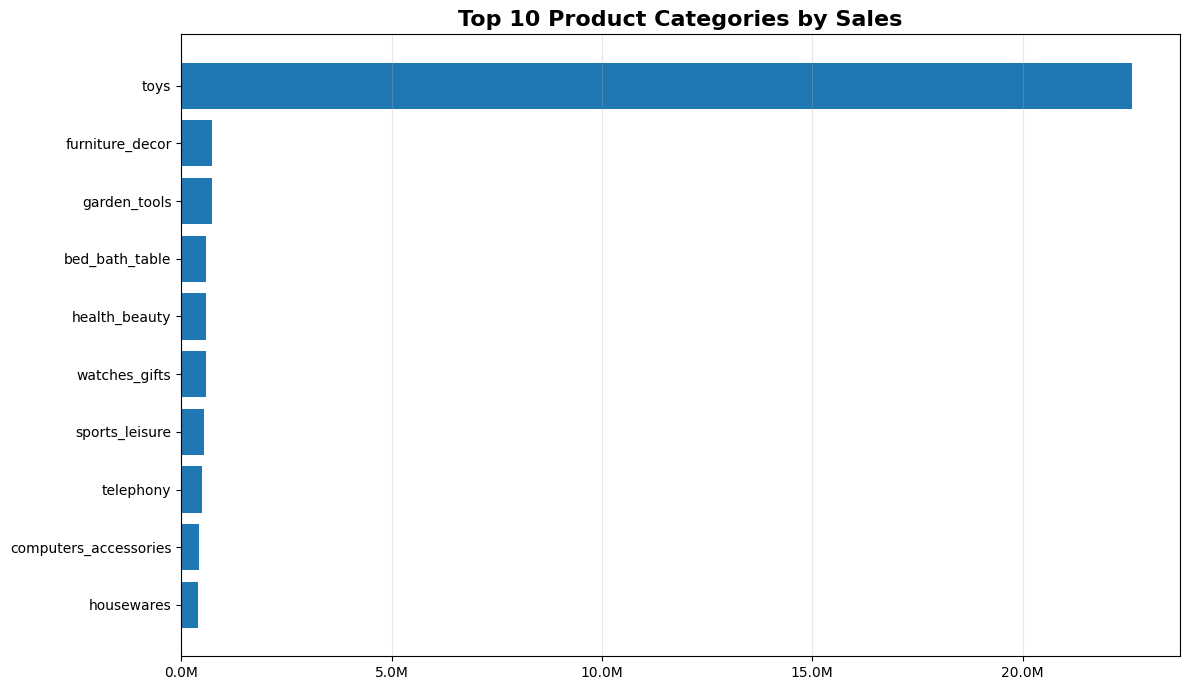

In [31]:
# Topn 10 Product Categories by Sales
product_category_plot = (
    product_category_df
    .sort_values("total_sales", ascending=True)
)

plt.figure(figsize=(12, 7))

plt.barh(
    product_category_plot["product_category_name"],
    product_category_plot["total_sales"]
)

plt.title(
    "Top 10 Product Categories by Sales",
    fontsize=16,
    fontweight="bold"
)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x/1_000_000:.1f}M"
    )
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [32]:
# Load Product Ranking Performance
product_ranking_query = """

SELECT
    oi.product_id,

    COUNT(DISTINCT o.order_id) AS total_orders,

    ROUND(
        SUM(oi.price),
        2
    ) AS total_sales,

    RANK() OVER(
        ORDER BY SUM(oi.price) DESC
    ) AS sales_rank

FROM ecommerce.orders AS o

JOIN ecommerce.order_items AS oi
    ON o.order_id = oi.order_id

WHERE
    o.order_status = 'delivered'

GROUP BY
    oi.product_id

ORDER BY
    sales_rank

LIMIT 10

"""

product_ranking_df = run_query(product_ranking_query)

product_ranking_df

,product_id,total_orders,total_sales,sales_rank
0,9NwzO0Pm0fDM,383,797298.940000000,1
1,SLTlrWtcYt1m,319,562443.450000000,2
2,Biwi1BNtUB7l,295,486503.650000000,3
3,ro08JPncYzLh,290,467133.530000000,4
4,ZWyg4uNWPHjJ,109,315991.000000000,5
5,tPlw2QcQOvKf,91,153366.490000000,6
6,utVPLgd1LM3F,75,142425.000000000,7
7,GvBzGCvvIC2D,175,126959.000000000,8
8,CY8OZ3lT9uqB,42,116979.980000000,9
9,5J7az1rwth4i,106,113008.920000000,10


## Delivery & Logistics Performance Visualization

Visualisasi ini digunakan untuk mengevaluasi performa proses pengiriman berdasarkan status ketepatan pengiriman, durasi pengiriman aktual dibandingkan estimasi, performa pengiriman berdasarkan wilayah, serta perubahan tingkat keterlambatan dari waktu ke waktu.

Analisis hanya menggunakan informasi pengiriman yang relevan untuk memahami efektivitas proses logistik dan mengidentifikasi area dengan potensi masalah pengiriman.

### Delivery Status Performance

In [33]:
# Load Delivery Status Performance
delivery_status_query = """

SELECT
    delivery_status,
    COUNT(order_id) AS total_orders,
    ROUND(
        AVG(delivery_days),
        2
    ) AS average_delivery_days

FROM ecommerce.orders

GROUP BY
    delivery_status

ORDER BY
    total_orders DESC

"""

delivery_status_df = run_query(delivery_status_query)

delivery_status_df

,delivery_status,total_orders,average_delivery_days
0,On Time,80689,10.86
1,Late,6738,31.32
2,Not Delivered,1889,NaN


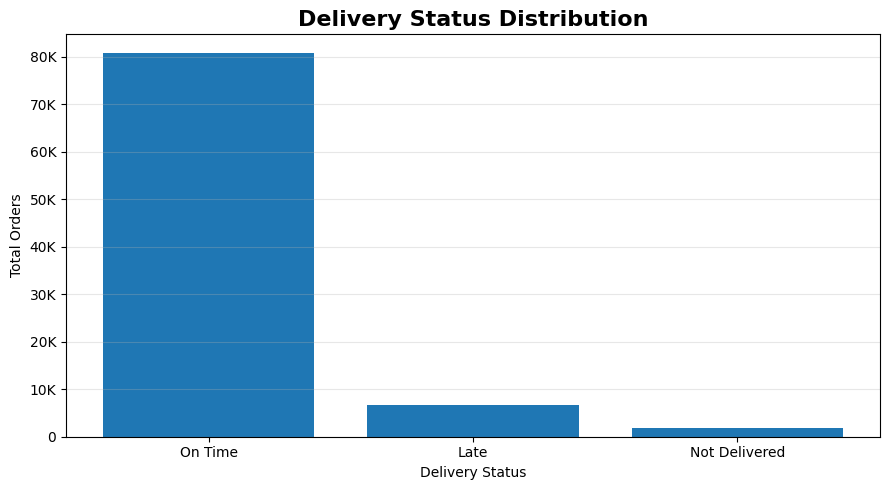

In [34]:
# Delivery Status Visualization
plt.figure(figsize=(9, 5))

bars = plt.bar(
    delivery_status_df["delivery_status"],
    delivery_status_df["total_orders"]
)

plt.title(
    "Delivery Status Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Delivery Status")
plt.ylabel("Total Orders")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x/1_000:.0f}K"
        if x >= 1_000
        else f"{x:.0f}"
    )
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Actual vs Estimated Delivery Time

In [38]:
# Load Actual vs Estimated Delivery Data
delivery_time_query = """

SELECT

    ROUND(
        AVG(delivery_days),
        2
    ) AS actual_delivery_days,

    ROUND(
        AVG(
            DATE_DIFF(
                order_estimated_delivery_date,
                DATE(order_purchase_timestamp),
                DAY
            )
        ),
        2
    ) AS estimated_delivery_days

FROM ecommerce.orders

WHERE
    order_status = 'delivered'

"""

delivery_time_df = run_query(delivery_time_query)

delivery_time_df

,actual_delivery_days,estimated_delivery_days
0,12.43,24.5


In [66]:
delivery_comparison_df = pd.DataFrame({
    "delivery_type": [
        "Actual Delivery",
        "Estimated Delivery"
    ],
    "average_days": [
        delivery_time_df["actual_delivery_days"][0],
        delivery_time_df["estimated_delivery_days"][0]
    ]
})

delivery_comparison_df

,delivery_type,average_days
0,Actual Delivery,12.43
1,Estimated Delivery,24.50


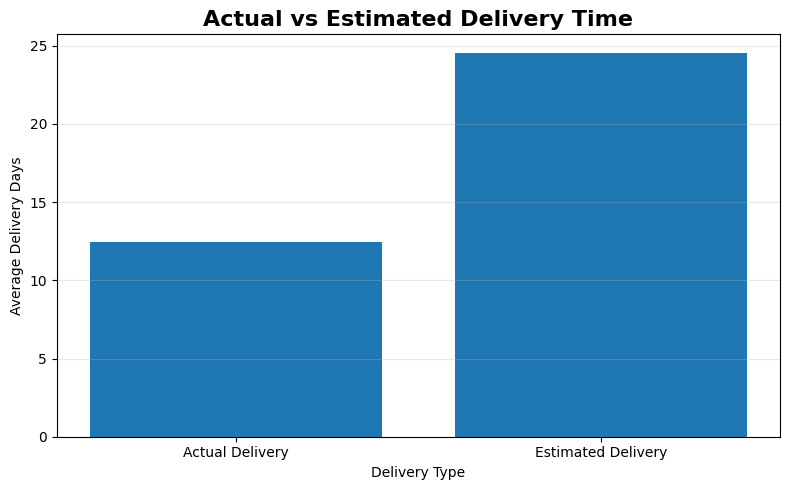

In [67]:
# Actual vs Estimated Delivery Visualization
plt.figure(figsize=(8, 5))

bars = plt.bar(
    delivery_comparison_df["delivery_type"],
    delivery_comparison_df["average_days"]
)

plt.title(
    "Actual vs Estimated Delivery Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Delivery Type")
plt.ylabel("Average Delivery Days")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Delivery Performance by State

In [40]:
# Load Delivery Performance by State
state_delivery_query = """

SELECT

    c.customer_state,

    COUNT(o.order_id) AS total_orders,

    COUNTIF(
        o.delivery_status = 'Late'
    ) AS late_orders,

    ROUND(
        SAFE_DIVIDE(
            COUNTIF(o.delivery_status = 'Late'),
            COUNTIF(
                o.delivery_status IN ('Late', 'On Time')
            )
        ) * 100,
        2
    ) AS late_delivery_rate,

    ROUND(
        AVG(o.delivery_days),
        2
    ) AS average_delivery_days

FROM ecommerce.orders AS o

JOIN ecommerce.customers AS c
    ON o.customer_id = c.customer_id

WHERE
    o.delivery_status != 'Not Delivered'

GROUP BY
    c.customer_state

ORDER BY
    late_delivery_rate DESC

LIMIT 10
"""

state_delivery_df = run_query(state_delivery_query)

state_delivery_df

,customer_state,total_orders,late_orders,late_delivery_rate,average_delivery_days
0,AL,325,79,24.31,24.71
1,MA,603,125,20.73,21.29
2,PI,409,67,16.38,19.02
3,SE,297,47,15.82,21.21
4,CE,1101,167,15.17,20.70
5,BA,3014,421,13.97,19.33
6,TO,243,31,12.76,17.34
7,RJ,11251,1428,12.69,15.21
8,PA,799,93,11.64,23.24
9,ES,1777,206,11.59,15.57


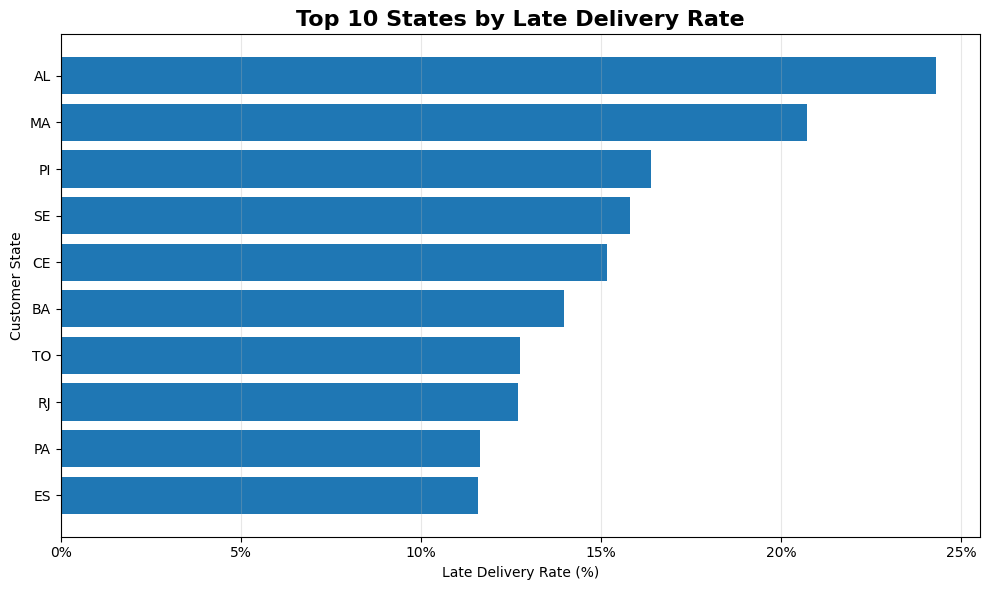

In [42]:
# Top 10 States by Late Delivery Rate
top_state_delivery = (
    state_delivery_df
    .sort_values(
        "late_delivery_rate",
        ascending=False
    )
    .head(10)
    .sort_values(
        "late_delivery_rate",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_state_delivery["customer_state"],
    top_state_delivery["late_delivery_rate"]
)

plt.title(
    "Top 10 States by Late Delivery Rate",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Customer State")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x:.0f}%"
    )
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Late Delivery Trend Over Time

In [43]:
# Load Monthly Late Delivery Trend
late_delivery_trend_query = """

WITH delivery_trend AS (

    SELECT

        DATE_TRUNC(
            DATE(order_purchase_timestamp),
            MONTH
        ) AS month_date,

        FORMAT_DATE(
            '%Y-%B',
            DATE(order_purchase_timestamp)
        ) AS purchase_month,

        COUNT(order_id) AS total_orders,

        ROUND(
            SAFE_DIVIDE(
                COUNTIF(delivery_status = 'Late'),
                COUNTIF(
                    delivery_status IN ('Late', 'On Time')
                )
            ) * 100,
            2
        ) AS late_delivery_rate

    FROM ecommerce.orders

    GROUP BY
        month_date,
        purchase_month
)

SELECT
    month_date,
    purchase_month,
    total_orders,
    late_delivery_rate

FROM delivery_trend

ORDER BY
    month_date ASC

"""

late_delivery_trend_df = run_query(
    late_delivery_trend_query
)

late_delivery_trend_df

,month_date,purchase_month,total_orders,late_delivery_rate
0,2016-09-01,2016-September,3,NaN
1,2016-10-01,2016-October,289,0.77
2,2016-12-01,2016-December,1,0.00
3,2017-01-01,2017-January,857,2.31
4,2017-02-01,2017-February,1534,3.20
5,2017-03-01,2017-March,2392,4.75
6,2017-04-01,2017-April,2156,7.35
7,2017-05-01,2017-May,3407,3.64
8,2017-06-01,2017-June,2953,3.61
9,2017-07-01,2017-July,3781,3.54


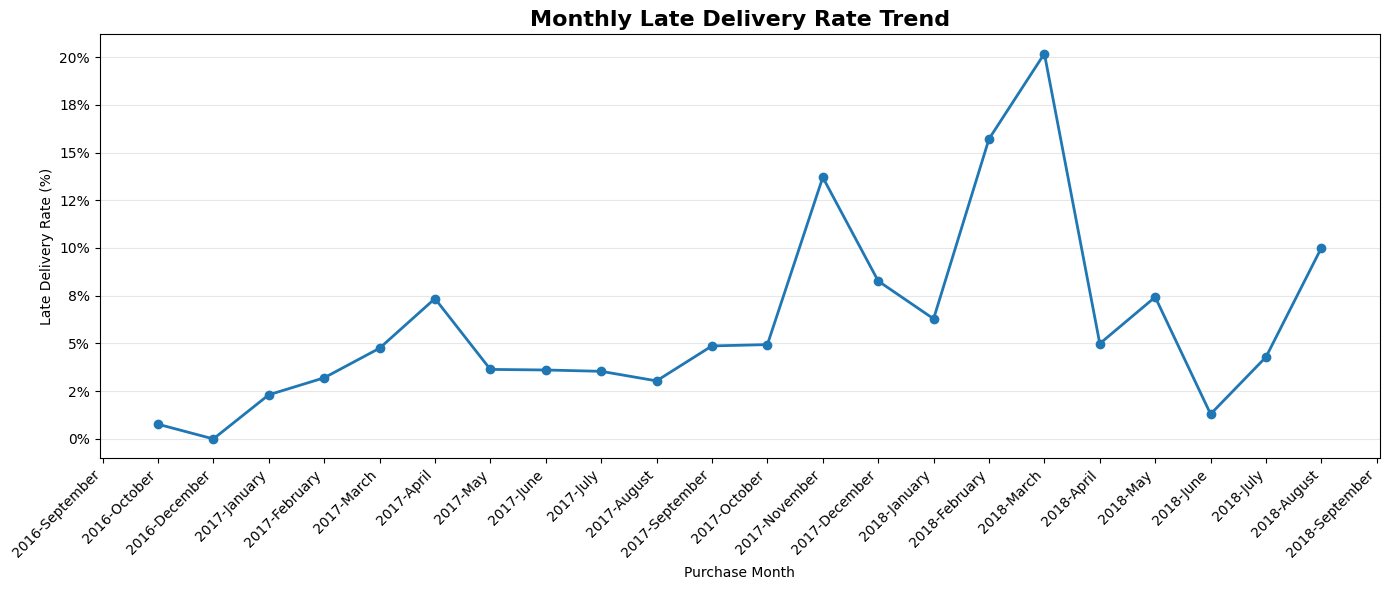

In [44]:
# Late Delivery Trend Visualization
plt.figure(figsize=(14, 6))

plt.plot(
    late_delivery_trend_df["purchase_month"],
    late_delivery_trend_df["late_delivery_rate"],
    marker="o",
    linewidth=2)

plt.title(
    "Monthly Late Delivery Rate Trend",
    fontsize=16,
    fontweight="bold")

plt.xlabel("Purchase Month")
plt.ylabel("Late Delivery Rate (%)")

plt.xticks(
    rotation=45,
    ha="right")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x:.0f}%"))
plt.grid(
    axis="y",
    alpha=0.3)

plt.tight_layout()
plt.show()

## Geographic Performance Visualization

Visualisasi ini digunakan untuk memahami persebaran customer dan performa bisnis berdasarkan wilayah.

Analisis geografis mencakup distribusi customer, kontribusi penjualan berdasarkan state, serta perbedaan nilai transaksi antar wilayah untuk mengidentifikasi pasar dengan aktivitas bisnis terbesar.

### Customer Distribution by State

In [45]:
# Load Customer Distribution by State
customer_state_query = """

SELECT
    c.customer_state,

    COUNT(DISTINCT c.customer_id) AS total_customers,

    COUNT(DISTINCT o.order_id) AS total_orders

FROM ecommerce.customers AS c

JOIN ecommerce.orders AS o
    ON c.customer_id = o.customer_id

WHERE
    o.order_status = 'delivered'

GROUP BY
    c.customer_state

ORDER BY
    total_orders DESC

"""

customer_state_df = run_query(customer_state_query)

customer_state_df

,customer_state,total_customers,total_orders
0,SP,37101,37101
1,RJ,11249,11249
2,MG,10172,10172
3,RS,4854,4854
4,PR,4451,4451
5,SC,3160,3160
6,BA,3014,3014
7,GO,1816,1816
8,ES,1777,1777
9,DF,1755,1755


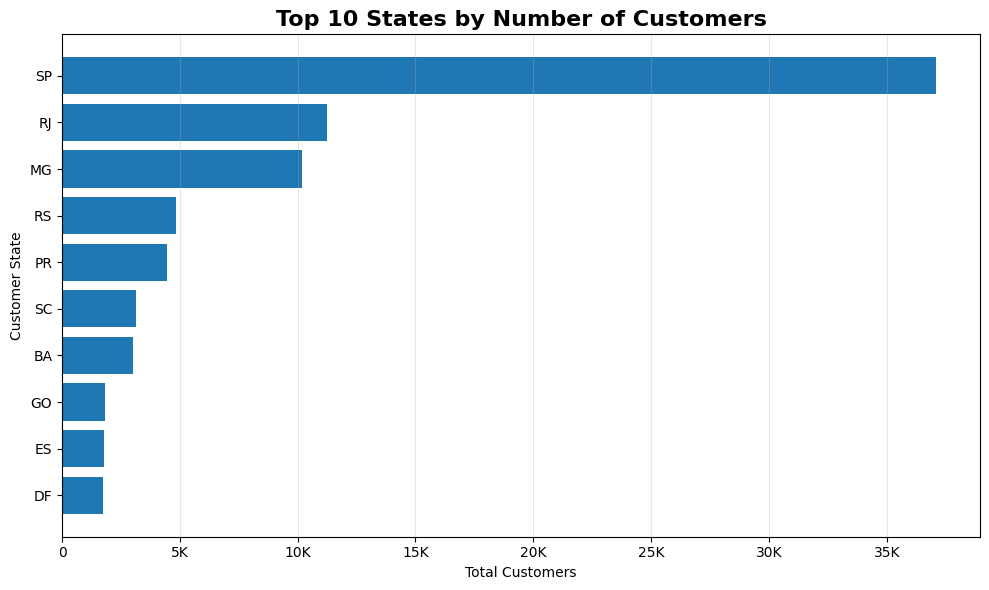

In [46]:
# Top 10 Customers by State Visualization
top_customer_state = (
    customer_state_df
    .sort_values("total_customers", ascending=False)
    .head(10)
    .sort_values("total_customers", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_customer_state["customer_state"],
    top_customer_state["total_customers"]
)

plt.title(
    "Top 10 States by Number of Customers",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Customers")
plt.ylabel("Customer State")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x/1_000:.0f}K"
        if x >= 1_000
        else f"{x:.0f}"
    )
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Sales Performance by State

In [47]:
# Sales Performance by State
state_sales_query = """

SELECT
    c.customer_state,

    COUNT(DISTINCT o.order_id) AS total_orders,

    ROUND(
        SUM(oi.price),
        2
    ) AS total_sales,

    ROUND(
        AVG(oi.order_value),
        2
    ) AS average_order_value

FROM ecommerce.orders AS o

JOIN ecommerce.order_items AS oi
    ON o.order_id = oi.order_id

JOIN ecommerce.customers AS c
    ON o.customer_id = c.customer_id

WHERE
    o.order_status = 'delivered'

GROUP BY
    c.customer_state

ORDER BY
    total_sales DESC

"""

state_sales_df = run_query(state_sales_query)

state_sales_df

,customer_state,total_orders,total_sales,average_order_value
0,SP,37101,12740951.710000000,386.920000000
1,RJ,11249,3755780.990000000,376.470000000
2,MG,10172,3465654.460000000,386.250000000
3,RS,4854,1645269.930000000,384.180000000
4,PR,4451,1580718.970000000,399.590000000
5,SC,3160,1051289.750000000,377.120000000
6,BA,3014,1041864.980000000,392.310000000
7,GO,1816,666349.990000000,411.640000000
8,ES,1777,611893.080000000,387.990000000
9,DF,1755,559149.880000000,360.170000000


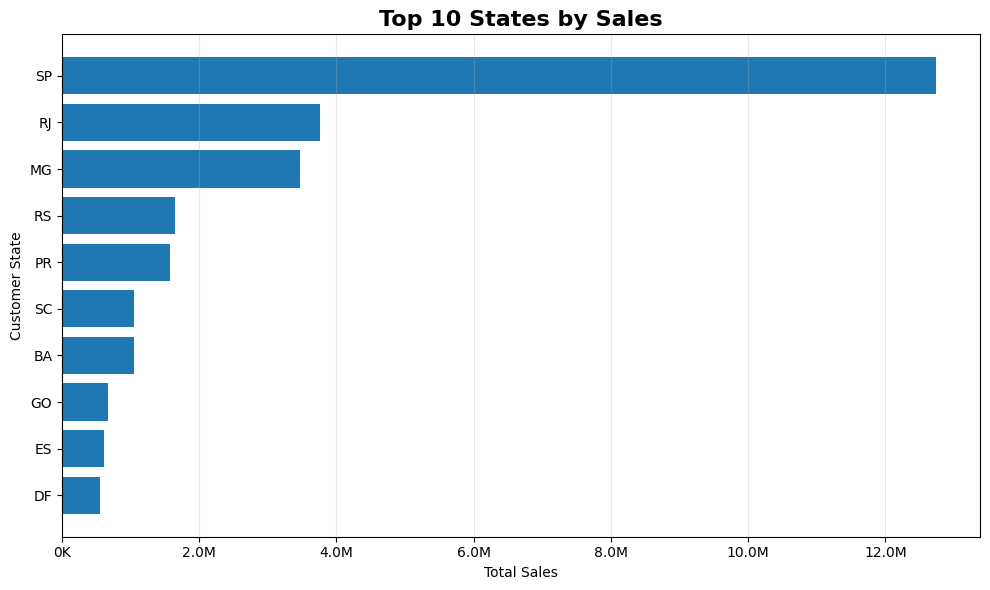

In [48]:
# Top 10 Sales Performance by State
top_state_sales = (
    state_sales_df
    .sort_values("total_sales", ascending=False)
    .head(10)
    .sort_values("total_sales", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_state_sales["customer_state"],
    top_state_sales["total_sales"]
)

plt.title(
    "Top 10 States by Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Sales")
plt.ylabel("Customer State")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x/1_000_000:.1f}M"
        if x >= 1_000_000
        else f"{x/1_000:.0f}K"
    )
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Sales Contribution by State

In [49]:
# Load Data Contribution by State
state_contribution_query = """

WITH state_sales AS (

    SELECT
        c.customer_state,
        SUM(oi.price) AS total_sales

    FROM ecommerce.orders AS o

    JOIN ecommerce.order_items AS oi
        ON o.order_id = oi.order_id

    JOIN ecommerce.customers AS c
        ON o.customer_id = c.customer_id

    WHERE
        o.order_status = 'delivered'

    GROUP BY
        c.customer_state
)

SELECT
    customer_state,

    ROUND(
        total_sales,
        2
    ) AS total_sales,

    ROUND(
        SAFE_DIVIDE(
            total_sales,
            SUM(total_sales) OVER()
        ) * 100,
        2
    ) AS sales_contribution_percent

FROM state_sales

ORDER BY
    total_sales DESC

"""

state_contribution_df = run_query(
    state_contribution_query
)

state_contribution_df

,customer_state,total_sales,sales_contribution_percent
0,SP,12740951.710000000,42.580000000
1,RJ,3755780.990000000,12.550000000
2,MG,3465654.460000000,11.580000000
3,RS,1645269.930000000,5.500000000
4,PR,1580718.970000000,5.280000000
5,SC,1051289.750000000,3.510000000
6,BA,1041864.980000000,3.480000000
7,GO,666349.990000000,2.230000000
8,ES,611893.080000000,2.040000000
9,DF,559149.880000000,1.870000000


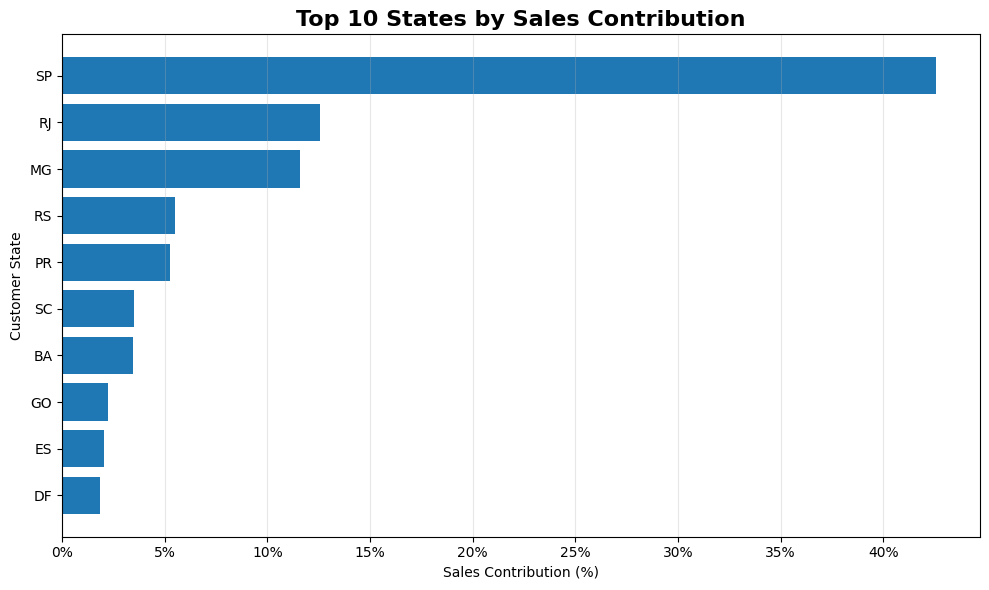

In [50]:
# Top 10 State by Sales Contribution Visualization
top_state_contribution = (
    state_contribution_df
    .head(10)
    .sort_values(
        "sales_contribution_percent",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_state_contribution["customer_state"],
    top_state_contribution["sales_contribution_percent"]
)

plt.title(
    "Top 10 States by Sales Contribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sales Contribution (%)")
plt.ylabel("Customer State")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x:.0f}%"
    )
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## Seller Performance Visualization  

Visualisasi ini digunakan untuk mengevaluasi performa seller berdasarkan kontribusi penjualan dan kualitas pengiriman. Analisis membantu mengidentifikasi seller dengan kontribusi bisnis terbesar serta seller yang memiliki potensi masalah pada proses delivery.

### Top Sellers by Sales

In [51]:
# Load Data Top Sellers by Sales
seller_sales_query = """

SELECT
    oi.seller_id,

    COUNT(DISTINCT o.order_id) AS total_orders,

    ROUND(
        SUM(oi.price),
        2
    ) AS total_sales,

    ROUND(
        AVG(oi.order_value),
        2
    ) AS average_order_value

FROM ecommerce.orders AS o

JOIN ecommerce.order_items AS oi
    ON o.order_id = oi.order_id

WHERE
    o.order_status = 'delivered'

GROUP BY
    oi.seller_id

ORDER BY
    total_sales DESC

LIMIT 10

"""

seller_sales_df = run_query(seller_sales_query)

seller_sales_df

,seller_id,total_orders,total_sales,average_order_value
0,r7VxefoTVHbb,1512,2562407.580000000,1735.360000000
1,yGbPyLPc8PmT,1586,1900070.900000000,1237.930000000
2,K0qPVGdA91KO,1151,663779.980000000,622.110000000
3,l1pYW6GBnPMr,905,474665.710000000,560.660000000
4,ruq0u2ZpAMDr,1284,419203.030000000,365.890000000
5,RKad98cTxhSb,1624,361091.930000000,272.880000000
6,EGW4UK5bOeEZ,1066,304213.080000000,331.470000000
7,yHsOFiqVrV1u,866,292845.580000000,384.540000000
8,BWczKEOZMEFy,300,278055.100000000,975.320000000
9,coi9xkdo66JI,869,238745.040000000,319.990000000


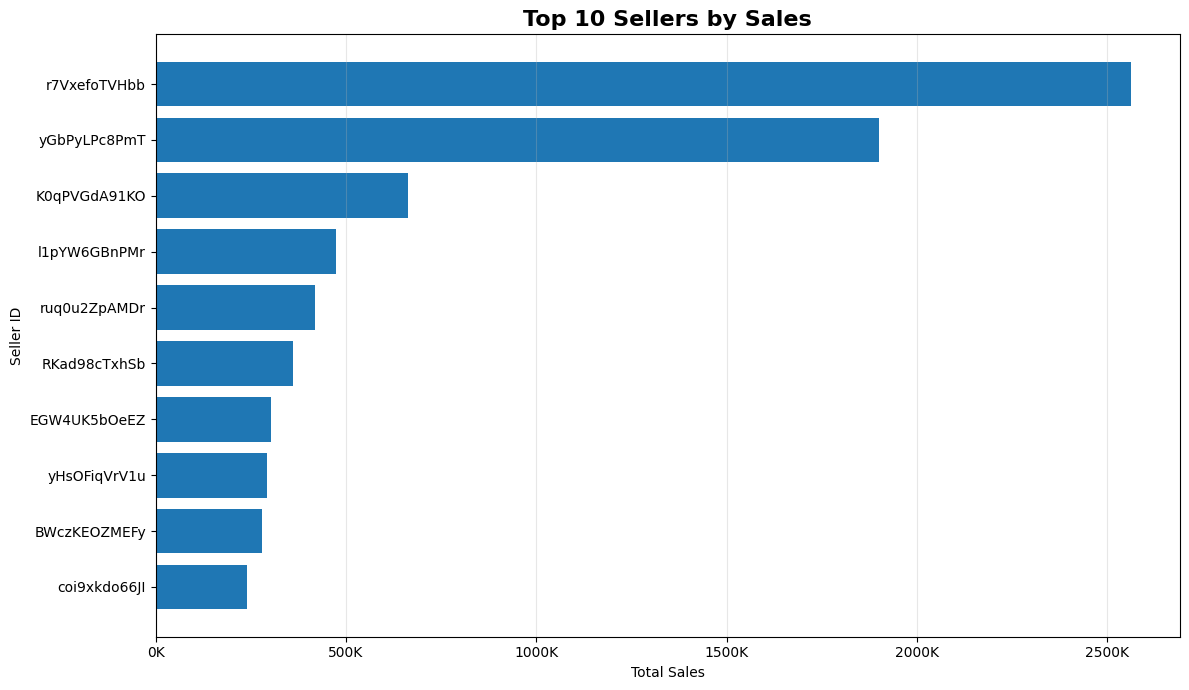

In [52]:
# Top 10 Sellers by Sales
seller_sales_plot = (
    seller_sales_df
    .sort_values("total_sales", ascending=True)
)

plt.figure(figsize=(12, 7))

plt.barh(
    seller_sales_plot["seller_id"],
    seller_sales_plot["total_sales"]
)

plt.title(
    "Top 10 Sellers by Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Sales")
plt.ylabel("Seller ID")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x/1_000:.0f}K"
    )
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Seller Delivery Performance

In [53]:
# Load Data Seller Delivery Performance
seller_delivery_query = """

SELECT
    oi.seller_id,

    COUNT(DISTINCT o.order_id) AS total_orders,

    COUNTIF(
        o.delivery_status = 'Late'
    ) AS late_orders,

    ROUND(
        SAFE_DIVIDE(
            COUNTIF(o.delivery_status = 'Late'),
            COUNTIF(
                o.delivery_status IN ('Late', 'On Time')
            )
        ) * 100,
        2
    ) AS late_delivery_rate

FROM ecommerce.orders AS o

JOIN ecommerce.order_items AS oi
    ON o.order_id = oi.order_id

WHERE
    o.delivery_status != 'Not Delivered'

GROUP BY
    oi.seller_id

HAVING
    total_orders >= 50

ORDER BY
    late_delivery_rate DESC

LIMIT 10

"""

seller_delivery_df = run_query(seller_delivery_query)

seller_delivery_df

,seller_id,total_orders,late_orders,late_delivery_rate
0,qeM9i4J3ypy2,57,17,29.82
1,aDQK7ytnBMNf,68,19,27.94
2,FBr7bTkcVwez,62,16,25.81
3,05nIYpVrMwiz,67,17,25.37
4,c1Dw1Rwr2Qdd,52,13,25.00
5,HaUIinFOemaU,295,72,24.41
6,8mVLKV0XOTsx,70,17,24.29
7,dMvfk1IQQJPl,104,23,22.12
8,ShJbjTW0ZGor,51,11,21.57
9,WjEwhmsH2ERN,61,13,21.31


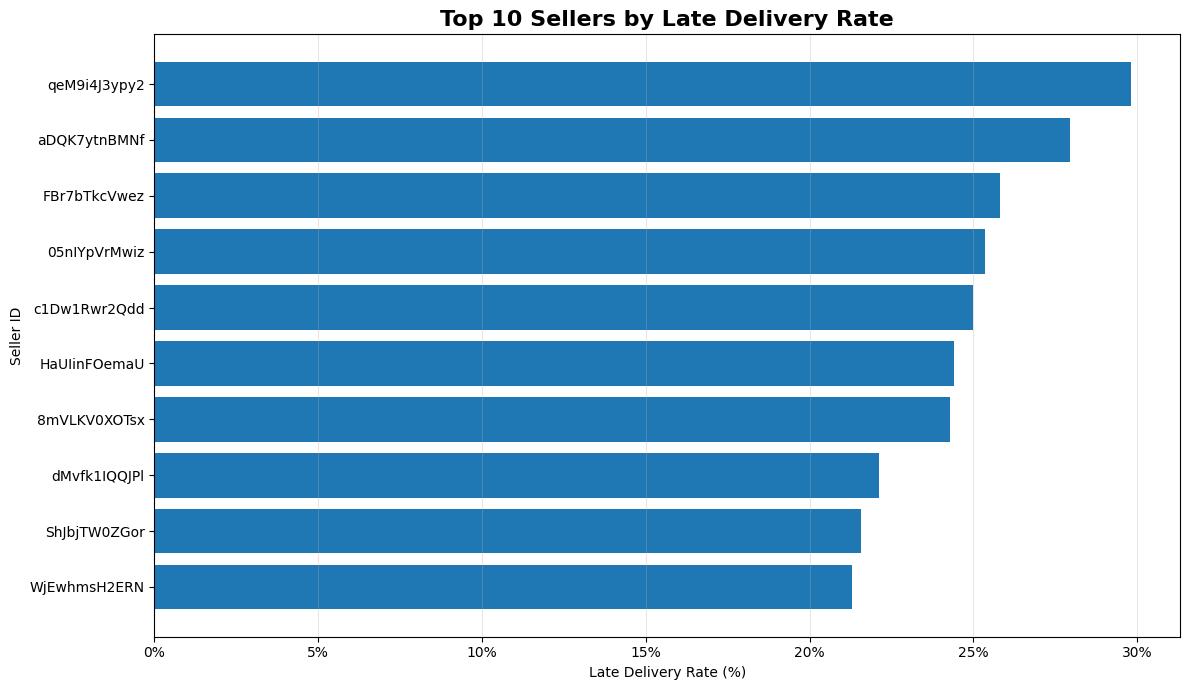

In [54]:
# Top 10 Sellers by Late Delivery Rate
seller_delivery_plot = (
    seller_delivery_df
    .sort_values(
        "late_delivery_rate",
        ascending=True
    )
)

plt.figure(figsize=(12, 7))

plt.barh(
    seller_delivery_plot["seller_id"],
    seller_delivery_plot["late_delivery_rate"]
)

plt.title(
    "Top 10 Sellers by Late Delivery Rate",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Seller ID")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x:.0f}%"
    )
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## Payment Analysis Visualization

Visualisasi ini digunakan untuk memahami perilaku pembayaran customer berdasarkan metode pembayaran yang digunakan dan pola penggunaan cicilan. Analisis membantu mengidentifikasi metode pembayaran yang paling dominan serta melihat hubungan antara jumlah cicilan dan nilai transaksi.

### Payment Method Distribution

In [55]:
# Load Data Payment Method
payment_method_query = """

SELECT
    payment_type,

    COUNT(DISTINCT order_id) AS total_orders,

    ROUND(
        SUM(payment_value),
        2
    ) AS total_payment_value,

    ROUND(
        AVG(payment_value),
        2
    ) AS average_payment_value

FROM ecommerce.payments

GROUP BY
    payment_type

ORDER BY
    total_orders DESC

"""

payment_method_df = run_query(payment_method_query)

payment_method_df

,payment_type,total_orders,total_payment_value,average_payment_value
0,credit_card,65814,17512576.650000000,266.090000000
1,wallet,17302,4642341.690000000,268.310000000
2,voucher,4911,1523103.470000000,310.140000000
3,debit_card,1289,317363.760000000,246.210000000


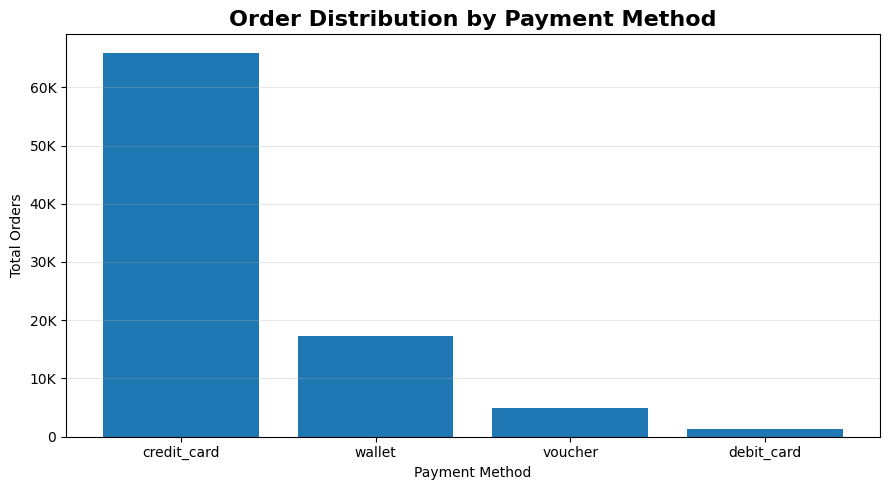

In [56]:
# Payment Method Distribution Visualization
plt.figure(figsize=(9, 5))

plt.bar(
    payment_method_df["payment_type"],
    payment_method_df["total_orders"]
)

plt.title(
    "Order Distribution by Payment Method",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Payment Method")
plt.ylabel("Total Orders")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x/1_000:.0f}K"
        if x >= 1_000
        else f"{x:.0f}"
    )
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Installment Behavior

In [57]:
# Load Data Payment Installment Behavior
installment_query = """

SELECT

    CASE

        WHEN payment_installments <= 1
            THEN '1 Installment'

        WHEN payment_installments BETWEEN 2 AND 6
            THEN '2-6 Installments'

        ELSE 'Above 6 Installments'

    END AS installment_group,

    COUNT(DISTINCT order_id) AS total_orders,

    ROUND(
        AVG(payment_value),
        2
    ) AS average_payment_value,

    ROUND(
        SUM(payment_value),
        2
    ) AS total_payment_value

FROM ecommerce.payments

GROUP BY
    installment_group

ORDER BY
    total_orders DESC

"""

installment_df = run_query(installment_query)

installment_df

,installment_group,total_orders,average_payment_value,total_payment_value
0,1 Installment,44316,269.740000000,11953868.520000000
1,2-6 Installments,33444,269.060000000,8998607.570000000
2,Above 6 Installments,11556,263.320000000,3042909.480000000


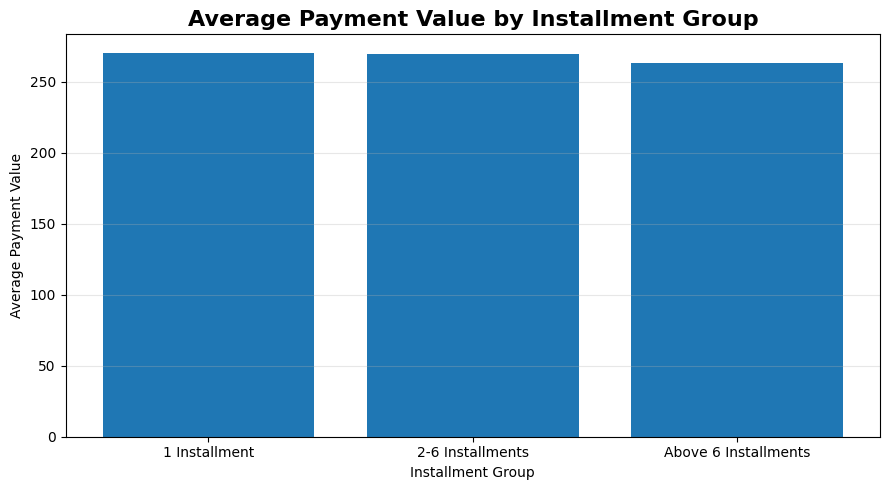

In [58]:
# Payment Installment Behavior Visualization
installment_plot = installment_df.copy()

order_mapping = {
    "1 Installment": 1,
    "2-6 Installments": 2,
    "Above 6 Installments": 3
}

installment_plot["sort_order"] = (
    installment_plot["installment_group"]
    .map(order_mapping)
)

installment_plot = (
    installment_plot
    .sort_values("sort_order")
)

plt.figure(figsize=(9, 5))

plt.bar(
    installment_plot["installment_group"],
    installment_plot["average_payment_value"]
)

plt.title(
    "Average Payment Value by Installment Group",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Installment Group")
plt.ylabel("Average Payment Value")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x:,.0f}"
    )
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## Advanced Analytics

Visualisasi ini digunakan untuk memperdalam analisis bisnis melalui segmentasi customer, konsentrasi revenue seller, serta performa produk individual.

Analisis mencakup:

- Customer Spending Segmentation
- Pareto Analysis
- Product Ranking Performance

### Customer Spending Segmentation

In [59]:
# Load Customer Spending Segmentation
customer_segment_query = """

WITH customer_spending AS (

    SELECT
        o.customer_id,
        SUM(p.payment_value) AS total_spending

    FROM ecommerce.orders AS o

    JOIN ecommerce.payments AS p
        ON o.order_id = p.order_id

    WHERE
        o.order_status = 'delivered'

    GROUP BY
        o.customer_id
),

customer_segment AS (

    SELECT
        customer_id,
        total_spending,

        CASE
            WHEN total_spending < 100
                THEN 'Low Spender'

            WHEN total_spending BETWEEN 100 AND 500
                THEN 'Medium Spender'

            ELSE 'High Spender'
        END AS spending_segment

    FROM customer_spending
)

SELECT
    spending_segment,
    COUNT(customer_id) AS total_customers,
    ROUND(AVG(total_spending), 2) AS average_spending,
    ROUND(SUM(total_spending), 2) AS total_spending

FROM customer_segment

GROUP BY
    spending_segment

ORDER BY
    total_customers DESC

"""

customer_segment_df = run_query(customer_segment_query)

customer_segment_df

,spending_segment,total_customers,average_spending,total_spending
0,Medium Spender,50377,231.780000000,11676611.190000000
1,Low Spender,26107,51.600000000,1347189.660000000
2,High Spender,10944,957.200000000,10475648.690000000


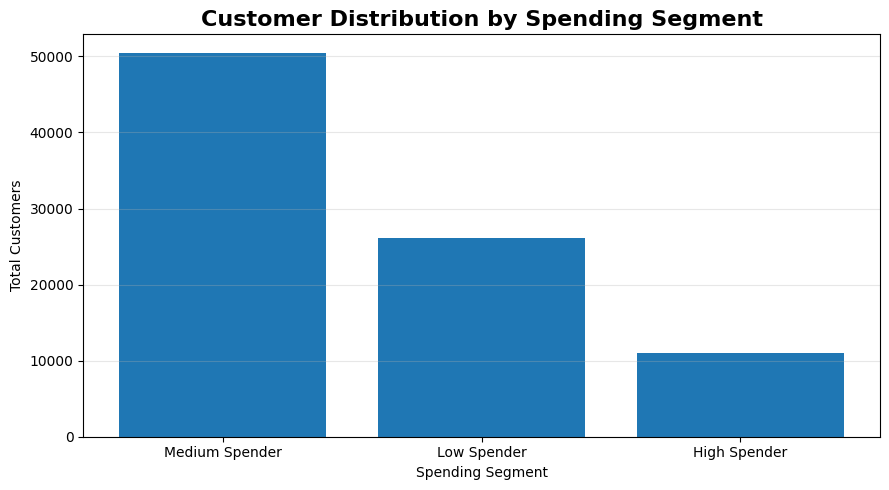

In [60]:
# Customer Spending Segmentation Visualization
plt.figure(figsize=(9, 5))

plt.bar(
    customer_segment_df["spending_segment"],
    customer_segment_df["total_customers"]
)

plt.title(
    "Customer Distribution by Spending Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Spending Segment")
plt.ylabel("Total Customers")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Pareto Analytics

In [61]:
# Load Pareto Analysis Data
pareto_query = """

WITH seller_sales AS (

    SELECT
        seller_id,
        SUM(price) AS total_sales

    FROM ecommerce.order_items

    GROUP BY
        seller_id
),

seller_rank AS (

    SELECT
        seller_id,
        total_sales,

        SUM(total_sales) OVER(
            ORDER BY total_sales DESC
        ) AS cumulative_sales,

        SUM(total_sales) OVER() AS overall_sales

    FROM seller_sales
)

SELECT
    seller_id,

    ROUND(
        total_sales,
        2
    ) AS total_sales,

    ROUND(
        SAFE_DIVIDE(
            cumulative_sales,
            overall_sales
        ) * 100,
        2
    ) AS cumulative_percentage

FROM seller_rank

ORDER BY
    total_sales DESC

"""

pareto_df = run_query(pareto_query)

pareto_df

,seller_id,total_sales,cumulative_percentage
0,r7VxefoTVHbb,2569785.560000000,8.440000000
1,yGbPyLPc8PmT,1923811.420000000,14.760000000
2,K0qPVGdA91KO,666339.920000000,16.950000000
3,l1pYW6GBnPMr,480706.200000000,18.530000000
4,ruq0u2ZpAMDr,422203.730000000,19.910000000
...,...,...,...
2924,DJJi40WZb02B,6.270000000,100.000000000
2925,WHCTdImrIp0y,0.850000000,100.000000000
2926,uzHNB354dHwV,0.850000000,100.000000000
2927,u0nbR1OriQlE,0.850000000,100.000000000


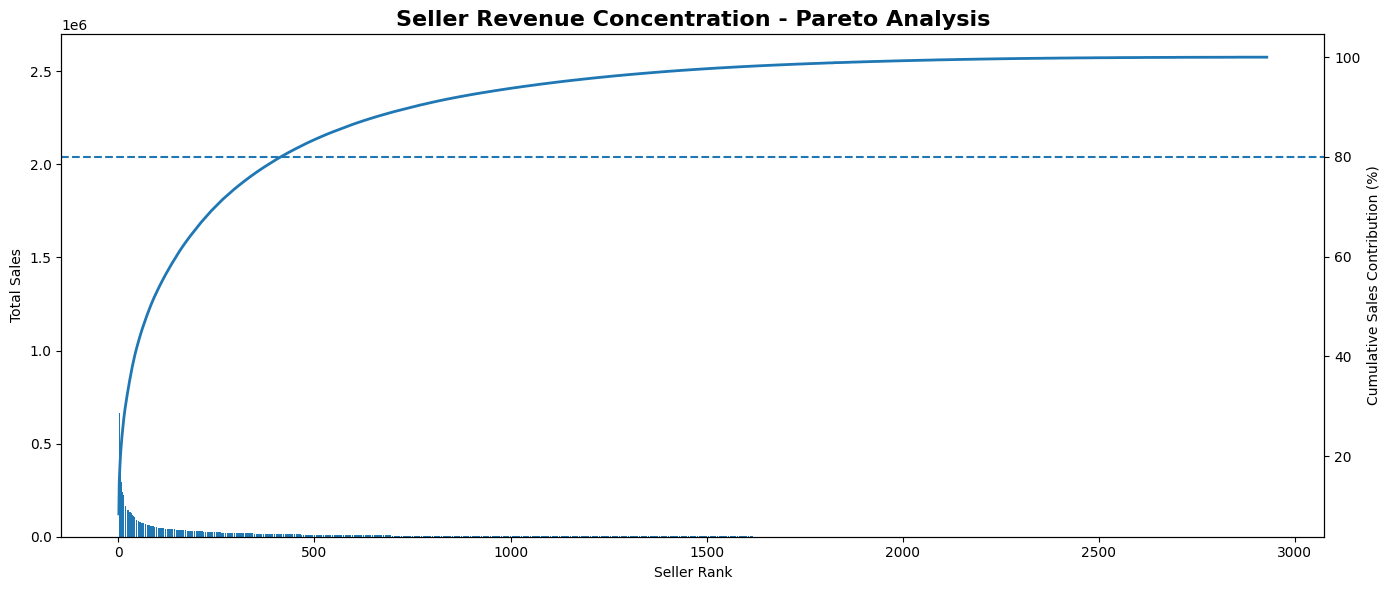

In [62]:
pareto_plot = pareto_df.copy()

pareto_plot = pareto_plot.reset_index(drop=True)

pareto_plot["seller_rank"] = (
    pareto_plot.index + 1
)

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(
    pareto_plot["seller_rank"],
    pareto_plot["total_sales"]
)

ax1.set_xlabel("Seller Rank")
ax1.set_ylabel("Total Sales")

ax2 = ax1.twinx()

ax2.plot(
    pareto_plot["seller_rank"],
    pareto_plot["cumulative_percentage"],
    linewidth=2
)

ax2.set_ylabel("Cumulative Sales Contribution (%)")

ax2.axhline(
    80,
    linestyle="--"
)

plt.title(
    "Seller Revenue Concentration - Pareto Analysis",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Product Ranking Performance

In [63]:
# Load Product Ranking Performance
product_ranking_query = """

SELECT
    oi.product_id,

    COUNT(DISTINCT o.order_id) AS total_orders,

    ROUND(
        SUM(oi.price),
        2
    ) AS total_sales,

    RANK() OVER(
        ORDER BY SUM(oi.price) DESC
    ) AS sales_rank

FROM ecommerce.orders AS o

JOIN ecommerce.order_items AS oi
    ON o.order_id = oi.order_id

WHERE
    o.order_status = 'delivered'

GROUP BY
    oi.product_id

ORDER BY
    sales_rank

LIMIT 10

"""

product_ranking_df = run_query(product_ranking_query)

product_ranking_df

,product_id,total_orders,total_sales,sales_rank
0,9NwzO0Pm0fDM,383,797298.940000000,1
1,SLTlrWtcYt1m,319,562443.450000000,2
2,Biwi1BNtUB7l,295,486503.650000000,3
3,ro08JPncYzLh,290,467133.530000000,4
4,ZWyg4uNWPHjJ,109,315991.000000000,5
5,tPlw2QcQOvKf,91,153366.490000000,6
6,utVPLgd1LM3F,75,142425.000000000,7
7,GvBzGCvvIC2D,175,126959.000000000,8
8,CY8OZ3lT9uqB,42,116979.980000000,9
9,5J7az1rwth4i,106,113008.920000000,10


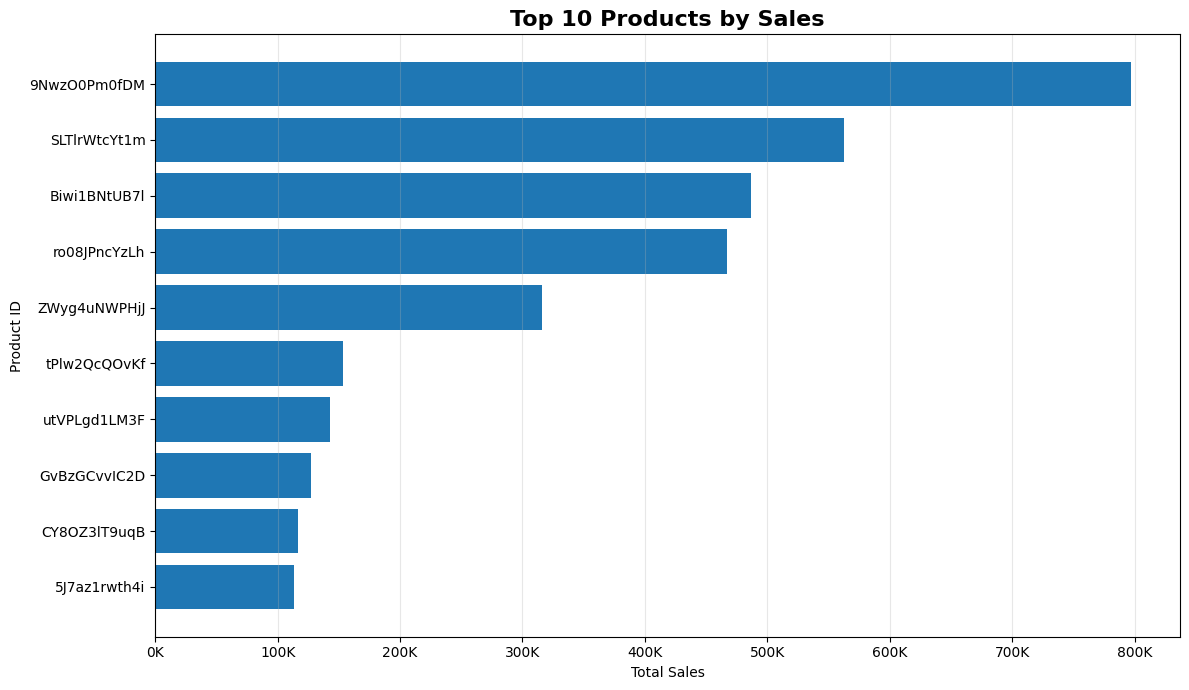

In [64]:
# Top 10 Product Ranking Performance
product_ranking_plot = (
    product_ranking_df
    .sort_values("total_sales", ascending=True)
)

plt.figure(figsize=(12, 7))

plt.barh(
    product_ranking_plot["product_id"],
    product_ranking_plot["total_sales"]
)

plt.title(
    "Top 10 Products by Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Sales")
plt.ylabel("Product ID")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x/1_000:.0f}K"
    )
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# Key Insights & Business Recommendations

## Key Insights

### 1. Sales & Order Performance
- November 2017 mencatat performa penjualan bulanan tertinggi dengan total sales sekitar **2.81 juta** dari **6.694 order**.
- Desember 2016 memiliki nilai penjualan terendah, namun periode tersebut hanya memiliki **1 order**, sehingga tidak cukup representatif untuk dibandingkan langsung dengan bulan lainnya.
- Secara umum, perubahan total sales bergerak searah dengan perubahan volume order, menunjukkan bahwa pertumbuhan penjualan banyak dipengaruhi oleh peningkatan jumlah transaksi.

### 2. Delivery & Logistics Performance
- Tingkat keterlambatan pengiriman secara keseluruhan berada di sekitar **7.71%** dari order yang memiliki informasi delivery lengkap.
- Mayoritas order berhasil dikirim tepat waktu, tetapi performa delivery berbeda antar wilayah dan seller.
- Perbedaan late delivery rate antar state menunjukkan bahwa tantangan logistik tidak tersebar secara merata dan membutuhkan perhatian berdasarkan wilayah.

### 3. Product Performance
- Product Category Performance menunjukkan bahwa kontribusi penjualan tidak tersebar secara merata di seluruh kategori.
- Product Ranking Analysis memberikan drill-down hingga level `product_id`, sehingga produk dengan kontribusi sales terbesar dapat diidentifikasi secara lebih spesifik.
- Produk dengan sales tinggi tidak selalu identik dengan produk yang memiliki volume order tertinggi, sehingga revenue dan demand perlu dianalisis secara bersamaan.

### 4. Seller Performance
- Seller memiliki kontribusi sales dan performa delivery yang berbeda-beda.
- Berdasarkan Pareto Analysis, **Top 50 seller menyumbang sekitar 42.74% dari total sales seluruh seller**.
- Hasil tersebut menunjukkan adanya konsentrasi revenue pada seller dengan performa tinggi, tetapi belum menunjukkan pola Pareto klasik 80/20 hanya pada 50 seller teratas.

### 5. Customer & Geographic Performance
- Aktivitas customer dan sales terkonsentrasi pada beberapa state utama, menunjukkan adanya wilayah yang memiliki kontribusi bisnis lebih besar dibandingkan wilayah lainnya.
- Customer Spending Segmentation membantu memisahkan customer berdasarkan tingkat spending sehingga strategi terhadap customer bernilai tinggi dapat dibedakan dari customer dengan spending lebih rendah.

### 6. Payment Behavior
- Credit card merupakan metode pembayaran yang paling dominan digunakan customer.
- Penggunaan installment menunjukkan pola spending yang berbeda antar kelompok cicilan, sehingga metode pembayaran dapat menjadi salah satu indikator perilaku transaksi customer.

## Business Recommendations

### 1. Strengthen Demand Planning During Peak Periods
Perusahaan dapat meningkatkan kesiapan inventory, seller capacity, dan logistics resources menjelang periode dengan peningkatan order yang tinggi. Performa November 2017 menunjukkan pentingnya perencanaan kapasitas pada periode peak sales.

### 2. Prioritize High-Contributing Products and Categories
Kategori dan produk dengan kontribusi sales tinggi dapat menjadi prioritas dalam inventory planning, promotional strategy, dan product availability. Namun, keputusan tidak hanya berdasarkan revenue, tetapi juga perlu mempertimbangkan volume order agar produk high-value dan high-demand dapat dibedakan.

### 3. Improve Logistics in High-Risk Regions
State dengan late delivery rate tinggi perlu dianalisis lebih lanjut untuk mengidentifikasi kemungkinan bottleneck dalam proses fulfillment dan pengiriman. Monitoring delivery performance sebaiknya dilakukan berdasarkan wilayah, bukan hanya secara keseluruhan.

### 4. Monitor Seller Performance Beyond Revenue
Seller dengan kontribusi sales tinggi perlu dipertahankan, tetapi performa delivery mereka juga perlu dipantau. Seller dengan volume transaksi besar dan late delivery rate tinggi dapat menjadi prioritas dalam evaluasi operasional.

### 5. Reduce Dependency on Revenue-Concentrated Sellers
Top 50 seller menyumbang sekitar 42.74% dari total sales. Perusahaan dapat menjaga hubungan dengan seller utama sekaligus mengembangkan seller dengan performa menengah agar kontribusi revenue lebih terdiversifikasi dan risiko ketergantungan dapat dikurangi.

### 6. Develop Customer Strategies Based on Spending Segments
Customer dengan spending tinggi dapat menjadi target untuk retention, loyalty, dan personalized offers, sementara kelompok medium dan low spender dapat diarahkan melalui strategi upselling atau targeted promotion.

### 7. Optimize Payment Strategy
Karena credit card menjadi metode pembayaran dominan, perusahaan dapat menjaga pengalaman pembayaran pada metode tersebut tetap optimal sekaligus mengevaluasi program installment sebagai strategi untuk mendukung transaksi bernilai lebih tinggi.